# Notebook de Exploración de Datos

---
## 1. Contexto del proyecto

**Proyecto:** Pipeline de datos previsionales (Chile)

**Objetivo:**
Explorar, entender y evaluar la calidad de los datasets de cotizaciones (CCICO)
y características de afiliados, para definir transformaciones y modelo de datos.

**Datasets:**
- informacion_mensual_ccico.csv
- caracteristicas_afiliados.csv

*Origen de los dataset:  Base de Datos de Historia Previsional de Afiliados (65,6 MB) (Fecha de cierre de la Base de Datos: DIC-2023).
Link: https://www.spensiones.cl/apps/bdp/index.php*

---
## 2. Carga de datos

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
DATA_PATH = Path("../data/raw/")

ccico = pd.read_csv(
    DATA_PATH / "informacion_mensual_ccico.csv",
    sep=";",
    dtype=str
)

afiliados = pd.read_csv(
    DATA_PATH / "caracteristicas_afiliados.csv",
    sep=";",
    dtype=str
)

---
## 3. CCICO: Limpieza y transformaciones

#### Explorar datos

In [3]:
print(f"FILAS/COLUMNAS: {ccico.shape}")
print(f"\nFILAS DUPLICADAS: {ccico.duplicated().sum().item()}")
print("\nCONTEO DE NULOS:")
print(ccico.isnull().sum().sort_values(ascending=False))
ccico.head()

FILAS/COLUMNAS: (5066318, 19)

FILAS DUPLICADAS: 12554

CONTEO DE NULOS:
bono_hijo                5065107
exc_lib_dis              5064970
rent_temp                5053493
ret_prog                 4765669
comi_p                   2227291
correl_pagador            281671
rem_imp                   281671
agno                           0
correl                         0
mes                            0
afp                            0
rem_imp_cero_flag              0
rem_imp_tope_flag              0
ret_prog_cero_flag             0
rent_temp_cero_flag            0
exc_lib_dis_cero_flag          0
bono_hijo_cero_flag            0
t_planilla                     0
rem_imp_min_flag               0
dtype: int64


,correl,correl_pagador,agno,mes,afp,rem_imp,ret_prog,rent_temp,exc_lib_dis,bono_hijo,comi_p,rem_imp_cero_flag,rem_imp_tope_flag,ret_prog_cero_flag,rent_temp_cero_flag,exc_lib_dis_cero_flag,bono_hijo_cero_flag,t_planilla,rem_imp_min_flag
0,00000622,08164024,1981,06,cup,0009000,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,3,0
1,00000622,08164024,1981,07,cup,0008000,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,3,0
2,00000622,90891111,1981,08,cup,0009000,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,3,0
3,00000622,08164024,1981,09,cup,0012000,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,3,0
4,00000622,08164024,1981,10,cup,0010000,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,3,0


#### Formar columna fecha uniendo año y mes

In [4]:
ccico["f_cotizacion"] = pd.to_datetime(ccico["agno"] + "-" + ccico["mes"],
                                errors="coerce")
ccico["f_cotizacion"].values

array(['1981-06-01T00:00:00.000000', '1981-07-01T00:00:00.000000',
       '1981-08-01T00:00:00.000000', ..., '2023-10-01T00:00:00.000000',
       '2023-11-01T00:00:00.000000', '2023-12-01T00:00:00.000000'],
      shape=(5066318,), dtype='datetime64[us]')

#### Seleccionar columnas a utilizar

In [5]:
ccico = ccico[["correl", "f_cotizacion", "afp", "rem_imp"]]

#### Renombrar columnas para mayor claridad

In [6]:
ccico = ccico.rename(columns={
    "correl": "id_afiliado",
    "rem_imp": "remuneracion"})

#### Eliminar filas duplicadas

In [7]:
ccico = ccico.drop_duplicates()

#### Cambiar tipos de datos

In [8]:
# Convertir números a enteros
ccico["id_afiliado"] = pd.to_numeric(ccico["id_afiliado"], errors="coerce").astype("Int64")
ccico["remuneracion"] = pd.to_numeric(ccico["remuneracion"], errors="coerce").astype("Int64")

#### Busqueda y limpieza de valores no válidos

In [9]:
# Obtner el rango de fechas de cotizaciones
print(f"Fecha mínima: {ccico['f_cotizacion'].min()}")
print(f"Fecha máxima: {ccico['f_cotizacion'].max()}")

Fecha mínima: 1981-05-01 00:00:00
Fecha máxima: 2023-12-01 00:00:00


In [10]:
# Contabilizar remuneraciones nulas o iguales a cero
print(f"Remuneraciones nulas: {ccico['remuneracion'].isnull().sum()}")
print(f"Remuneraciones iguales o menores a cero: {(ccico['remuneracion'] <= 0).sum()}")

Remuneraciones nulas: 260761
Remuneraciones iguales o menores a cero: 4723


In [11]:
# Eliminar filas con remuneraciones nulas y remuneraciones menores oiguales a cero
# ya que no aportan información útil
ccico = ccico.dropna(subset=["remuneracion"])
ccico = ccico[ccico["remuneracion"] > 0]

#### Otras transformaciones

In [12]:
# Convertir códigos de AFP a nombres legibles
print(ccico["afp"].unique())
afp_mapping = {
    "cup": "CUPRUM",
    "prv": "PROVIDA",
    "hab": "HABITAT",
    "cap": "CAPITAL",
    "pli": "PLANVITAL",
    "mod": "MODELO",
    "uno": "UNO",
}
ccico["afp"] = ccico["afp"].map(afp_mapping)
ccico["afp"].unique()

<ArrowStringArray>
['cup', 'prv', 'hab', 'cap', 'pli', 'mod', 'uno']
Length: 7, dtype: str


<ArrowStringArray>
['CUPRUM', 'PROVIDA', 'HABITAT', 'CAPITAL', 'PLANVITAL', 'MODELO', 'UNO']
Length: 7, dtype: str

#### Observar cambios

In [13]:
print(f"FILAS/COLUMNAS: {ccico.shape}")
print(f"\nFILAS DUPLICADAS: {ccico.duplicated().sum().item()}")
print("\nTIPOS DE DATOS:")
print(ccico.dtypes)
print("\nCONTEO DE NULOS:")
print(ccico.isnull().sum().sort_values(ascending=False))
ccico.head()

FILAS/COLUMNAS: (4763680, 4)

FILAS DUPLICADAS: 0

TIPOS DE DATOS:
id_afiliado              Int64
f_cotizacion    datetime64[us]
afp                        str
remuneracion             Int64
dtype: object

CONTEO DE NULOS:
id_afiliado     0
f_cotizacion    0
afp             0
remuneracion    0
dtype: int64


,id_afiliado,f_cotizacion,afp,remuneracion
0,622,1981-06-01,CUPRUM,9000
1,622,1981-07-01,CUPRUM,8000
2,622,1981-08-01,CUPRUM,9000
3,622,1981-09-01,CUPRUM,12000
4,622,1981-10-01,CUPRUM,10000


---
## 4. AFILIADOS: Limpieza y transformaciones

#### Explorar datos

In [14]:
print(f"FILAS/COLUMNAS: {afiliados.shape}")
print(f"\nFILAS DUPLICADAS: {afiliados.duplicated().sum().item()}")
print("\nCONTEO DE NULOS:")
print(afiliados.isnull().sum().sort_values(ascending=False))
afiliados.head()

FILAS/COLUMNAS: (28880, 43)

FILAS DUPLICADAS: 0

CONTEO DE NULOS:
fecha_cmp                 28320
monto_pri                 27003
monto_pen                 27002
saldoE_pesos              26212
monto_bono                25807
fec_bono                  25807
estado_bono               25807
saldoA_pesos              25788
num_mes_cot_ips           24953
prom_rta                  22570
mto_ult                   22339
per_dev_uc                22339
fecha_sol                 21955
modpen                    21955
tipopen                   21955
pafe                      21920
saldoC_pesos              21309
saldoB_pesos              20482
saldoD_pesos              19976
region                      386
fecha_nac                     3
fecha_fall                    0
idnexissal                    0
nac                           0
sexo                          0
correl                        0
fecha_afil                    0
afp                           0
idp                           0
tiene

,correl,sexo,fecha_nac,nac,region,fecha_fall,fecha_afil,afp,idnexissal,saldoA_pesos,...,tiene_cciav,tiene_capvc,saldoA_pesos_cero_flag,saldoB_pesos_cero_flag,saldoC_pesos_cero_flag,saldoD_pesos_cero_flag,saldoE_pesos_cero_flag,monto_bono_cero_flag,monto_pen_cero_flag,monto_pri_cero_flag
0,01282203,M,191208,C,05,199504,198105,HABITAT,00000,NaN,...,0,0,0,0,0,0,0,0,0,0
1,03159724,M,191601,C,13,201207,199005,PROVIDA,00010,NaN,...,0,0,0,0,0,1,0,0,0,0
2,01317456,M,190905,C,10,199709,198505,HABITAT,00010,NaN,...,0,0,0,0,0,0,0,0,0,0
3,01325679,M,191306,C,15,200501,198510,HABITAT,00010,NaN,...,0,0,0,0,0,1,0,0,0,0
4,06098138,M,191109,C,13,198801,198509,PROVIDA,00010,NaN,...,0,0,0,0,0,0,0,0,0,0


#### Calcular columna saldo_pension

In [15]:
afiliados["saldo_pension"] = (
    pd.to_numeric(afiliados["saldoA_pesos"], errors="coerce").astype("Int64").fillna(0)
    + pd.to_numeric(afiliados["saldoB_pesos"], errors="coerce").astype("Int64").fillna(0)
    + pd.to_numeric(afiliados["saldoC_pesos"], errors="coerce").astype("Int64").fillna(0)
    + pd.to_numeric(afiliados["saldoD_pesos"], errors="coerce").astype("Int64").fillna(0)
    + pd.to_numeric(afiliados["saldoE_pesos"], errors="coerce").astype("Int64").fillna(0)
)

#### Seleccionar columnas a utilizar

In [16]:
afiliados = afiliados[[
        "correl", "sexo", "nac", "region", "fecha_nac", "fecha_fall",
        "afp", "saldo_pension"]]

#### Renombrar columnas para mayor claridad

In [17]:
afiliados = afiliados.rename(
    columns={
        "correl": "id_afiliado",
        "nac": "nacionalidad",
        "fecha_nac": "f_nacimiento",
        "fecha_fall": "f_fallecimiento",
        "afp": "afp_actual",
    }
)

#### Cambiar tipos de datos

In [18]:
# Convertir números a enteros
afiliados["id_afiliado"] = (
    pd.to_numeric(afiliados["id_afiliado"], errors="coerce").astype("Int64")
)

In [19]:
# Convertir fechas a formato datetime
afiliados["f_nacimiento"] = pd.to_datetime(
    afiliados["f_nacimiento"], format="%Y%m", errors="coerce"
)
afiliados["f_fallecimiento"] = pd.to_datetime(
    afiliados["f_fallecimiento"], format="%Y%m", errors="coerce"
)

#### Busqueda y limpieza de valores no válidos

In [20]:
print(f"Valores de sexo: {afiliados["sexo"].unique()}")
print(f"Valores de nacionalidad: {afiliados["nacionalidad"].unique()}")
print(f"Valores de región: {afiliados["region"].unique()}")


Valores de sexo: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
Valores de nacionalidad: <ArrowStringArray>
['C', 'E']
Length: 2, dtype: str
Valores de región: <ArrowStringArray>
['05', '13', '10', '15', '08', '06', '03', '09', '12', '02', '11', '14', '04',
  nan, '16', '07', '01']
Length: 17, dtype: str


In [21]:
# Contar fechas de nacimiento nulas
print(f"Fechas de nacimiento nulas: {afiliados['f_nacimiento'].isnull().sum()}")
# Eliminar filas con fechas de nacimiento nulas
afiliados = afiliados.dropna(subset=["f_nacimiento"])

Fechas de nacimiento nulas: 3


In [22]:
# Contar filas donde la fecha de fallecimiento es anterior a la fecha de nacimiento
print(f"Fechas de fallecimiento anteriores a nacimiento: {(afiliados['f_fallecimiento'] < afiliados['f_nacimiento']).sum()}")

Fechas de fallecimiento anteriores a nacimiento: 0


In [23]:
# Obtener edad maxima de afiliados vivos
afiliados_vivos = afiliados[afiliados["f_fallecimiento"].isnull()]
edad_maxima = (pd.Timestamp.now() - afiliados_vivos["f_nacimiento"]).dt.days // 365
print(f"Edad máxima de afiliados vivos: {edad_maxima.max()}")

# Contar afiliados vivos mayores de 110 años
afiliados_vivos_mayores_110 = afiliados_vivos[edad_maxima > 110]
print(f"Afiliados vivos mayores de 110 años: {afiliados_vivos_mayores_110.shape[0]}")

# Eliminar fila del afiliado vivo mayor de 110 años, ya que es un caso extremo que podría ser un error de datos
afiliados = afiliados[afiliados["id_afiliado"] != afiliados_vivos_mayores_110["id_afiliado"].iloc[0]]

Edad máxima de afiliados vivos: 125
Afiliados vivos mayores de 110 años: 1


#### Otras Transformaciones

In [24]:
# Mapear nacionalidad a categorías más legibles
nacionalidad_mapping = {
    "C": "chilena",
    "E": "extranjera"
}
afiliados["nacionalidad"] = afiliados["nacionalidad"].map(nacionalidad_mapping)
afiliados["nacionalidad"].unique()

<ArrowStringArray>
['chilena', 'extranjera']
Length: 2, dtype: str

In [25]:
# Mapear región a nombres legibles
region_mapping = {
    "01": "Tarapacá",
    "02": "Antofagasta",
    "03": "Atacama",
    "04": "Coquimbo",
    "05": "Valparaíso",
    "06": "O'Higgins",
    "07": "Maule",
    "08": "Biobío",
    "09": "Araucanía",
    "10": "Los Lagos",
    "11": "Aisén",
    "12": "Magallanes",
    "13": "Metropolitana",
    "14": "Los Ríos",
    "15": "Arica y Parinacota",
    "16": "Ñuble",
    np.nan: "Desconocida",
}
afiliados["region"] = afiliados["region"].map(region_mapping)
afiliados["region"].unique()

<ArrowStringArray>
[        'Valparaíso',      'Metropolitana',          'Los Lagos',
 'Arica y Parinacota',             'Biobío',          'O'Higgins',
            'Atacama',          'Araucanía',         'Magallanes',
        'Antofagasta',              'Aisén',           'Los Ríos',
           'Coquimbo',        'Desconocida',              'Ñuble',
              'Maule',           'Tarapacá']
Length: 17, dtype: str

#### Observar cambios

In [26]:
print(f"FILAS/COLUMNAS: {afiliados.shape}")
print(f"\nFILAS DUPLICADAS: {afiliados.duplicated().sum().item()}")
print("\nTIPOS DE DATOS:")
print(afiliados.dtypes)
print("\nCONTEO DE NULOS:")
print(afiliados.isnull().sum().sort_values(ascending=False))
afiliados.head()


FILAS/COLUMNAS: (28876, 8)

FILAS DUPLICADAS: 0

TIPOS DE DATOS:
id_afiliado                 Int64
sexo                          str
nacionalidad                  str
region                        str
f_nacimiento       datetime64[us]
f_fallecimiento    datetime64[us]
afp_actual                    str
saldo_pension               Int64
dtype: object

CONTEO DE NULOS:
f_fallecimiento    26112
id_afiliado            0
nacionalidad           0
sexo                   0
region                 0
f_nacimiento           0
afp_actual             0
saldo_pension          0
dtype: int64


,id_afiliado,sexo,nacionalidad,region,f_nacimiento,f_fallecimiento,afp_actual,saldo_pension
0,1282203,M,chilena,Valparaíso,1912-08-01,1995-04-01,HABITAT,0
1,3159724,M,chilena,Metropolitana,1916-01-01,2012-07-01,PROVIDA,0
2,1317456,M,chilena,Los Lagos,1909-05-01,1997-09-01,HABITAT,350000
3,1325679,M,chilena,Arica y Parinacota,1913-06-01,2005-01-01,HABITAT,0
4,6098138,M,chilena,Metropolitana,1911-09-01,1988-01-01,PROVIDA,0


---
## 5. Análisis exploratorio básico

#### Unión preliminar para análisis

In [27]:
# Unión preliminar para validación
df = pd.merge(afiliados, ccico, on="id_afiliado", how="left")
print(f"Filas/Columnas: {df.shape}")
df.head()


Filas/Columnas: (4764502, 11)


,id_afiliado,sexo,nacionalidad,region,f_nacimiento,f_fallecimiento,afp_actual,saldo_pension,f_cotizacion,afp,remuneracion
0,1282203,M,chilena,Valparaíso,1912-08-01,1995-04-01,HABITAT,0,1981-06-01,HABITAT,12000
1,3159724,M,chilena,Metropolitana,1916-01-01,2012-07-01,PROVIDA,0,1990-05-01,PROVIDA,33000
2,3159724,M,chilena,Metropolitana,1916-01-01,2012-07-01,PROVIDA,0,1990-06-01,PROVIDA,29000
3,3159724,M,chilena,Metropolitana,1916-01-01,2012-07-01,PROVIDA,0,1990-07-01,PROVIDA,36000
4,3159724,M,chilena,Metropolitana,1916-01-01,2012-07-01,PROVIDA,0,1990-08-01,PROVIDA,30000


#### Análisis de Remuneraciones

<Axes: title={'center': 'Evolución de Remuneración Imponible en el Tiempo'}, xlabel='Fecha', ylabel='Remuneración Imponible Promedio'>

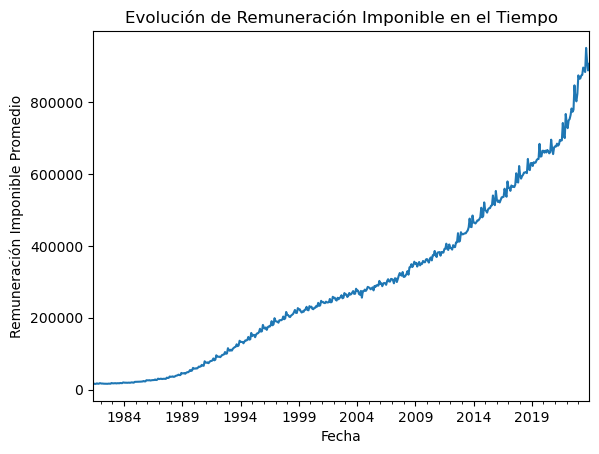

In [28]:
# Evolución de remuneraciones en el tiempo
df.groupby("f_cotizacion")["remuneracion"].mean().plot(
    title="Evolución de Remuneración Imponible en el Tiempo",
    xlabel="Fecha",
    ylabel="Remuneración Imponible Promedio",
)

In [29]:
# Remuneraciones promedio y máximas de mujeres y hombres
resultado = df.groupby("sexo")["remuneracion"].agg(["mean", "max"])
resultado["mean"] = resultado["mean"].astype(int)
resultado

,mean,max
sexo,,
F,363876,5279000
M,415468,8393000


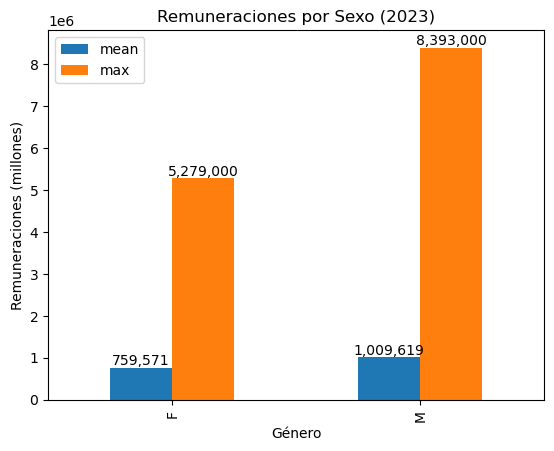

In [30]:
# Analizar Brecha salarial en 2023 (año más reciente de los datos)

# Filtrar registros del año 2023
df_2023 = df[df["f_cotizacion"].dt.year == 2023]

# Remuneraciones promedio y máximas de mujeres y hombres
resultado = df_2023.groupby("sexo")["remuneracion"].agg(["mean", "max"])
ax = resultado.plot(
    kind="bar",
    title="Remuneraciones por Sexo (2023)",
    xlabel="Género",
    ylabel="Remuneraciones (millones)",
)
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x:,.0f}")


#### Análisis por AFP

<Axes: title={'center': 'Cantidad de Afiliados por AFP'}, xlabel='Cantidad de Afiliados', ylabel='AFP'>

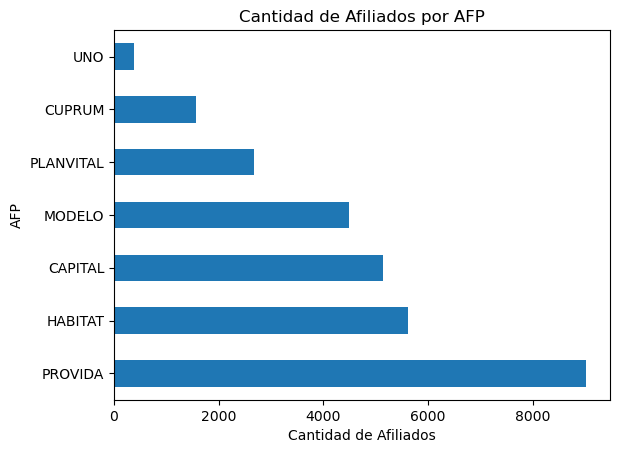

In [31]:
afiliados["afp_actual"].value_counts().plot(
    kind="barh", title="Cantidad de Afiliados por AFP", xlabel="Cantidad de Afiliados", ylabel="AFP"
)

<Axes: title={'center': 'Saldo de Pensión Promedio por AFP'}, xlabel='AFP', ylabel='Saldo de Pensión Promedio (millones)'>

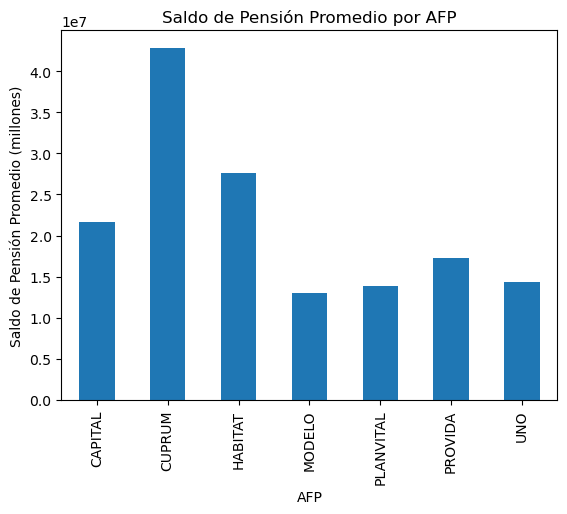

In [32]:
# Grafico de saldos de pensión promedio por AFP
df.groupby("afp_actual")["saldo_pension"].mean().plot(
    kind="bar",
    title="Saldo de Pensión Promedio por AFP",
    xlabel="AFP",
    ylabel="Saldo de Pensión Promedio (millones)",
)

---
## 6. Hallazgos

### CCICO.
- El dataset posse `5.066.318` filas y `19` Columnas.
- Existen `12.554` filas duplicadas.
- Existen `260.761` filas donde la remuneración es un valor Null.
- Existen `4.723` filas donde la remuneración es igual a cero.
- La fecha de la cotización esta separada en los campos año y mes.
- El campo `correl (id_afiliado)` requiere ser transformado a entero.
- El campo `rem_imp (rumeneracion)` requiere ser transformado a entero.
- El campo `afp` requiere ser mapeado.

### Afiliados
- El conjunto de datos posse `28.880` filas y `43` Columnas
- No existen filas duplicadas
- Existen `386` filas donde la region tiene un valor Null
- Existen `3` filas donde la fecha de nacimiento tiene un valor Null
- Las fechas están en formato `YYYYMM` y requieren conversión
- El campo `correl (id_afiliado)` requiere ser transformado a entero
- Se encontró un registro plausiblemte erróneo de un afiliado vivo de 125 años de edad
- Las columnas nacionalidad y región requieren ser mapeadas a valores mas legibles

### Otros hallazgos
- Calidad de datos:
    - Se detectaron valores nulos, ceros y formatos inconsistentes en múltiples columnas, lo que requirió procesos de limpieza y estandarización.
    - Esto evidencia que los datos no están listos para análisis directo y requieren una etapa de transformación previa.
- Representatividad de los datos:
    - Los datos representan la remuneracion imponible de los afiliados al momento de pagar sus cotizaciones entre los años 1981 al 2023.
- Granularidad del dataset:
    - El dataset de cotizaciones (ccico) presenta granularidad mensual por afiliado, lo que permite realizar análisis temporales del comportamiento previsional.
    - Esto habilita estudios de evolución individual, densidad de cotizaciones y trayectorias laborales.
- Integración de fuentes:
    - La combinación de datos de cotizaciones y características de afiliados permite enriquecer el análisis, incorporando variables demográficas como sexo, y región.
    - Esto habilita segmentaciones más profundas del comportamiento previsional.
- Lagunas previsionales:
    - Se observa una alta proporción de registros sin remuneración imponible, lo que sugiere la existencia de lagunas previsionales en los afiliados.
    - Esto indica periodos sin cotización, lo cual puede impactar directamente en el monto de pensión futura.
- Alta variabilidad de ingresos:
    - La distribución de la remuneración imponible presenta alta dispersión, con concentración en tramos bajos y presencia de valores extremos.
    - Esto sugiere desigualdad en la capacidad de cotización.
- Evolución temporal de ingresos:
    - La evolución temporal del ingreso promedio muestra variaciones a lo largo del tiempo, que pueden estar influenciadas por factores macroeconómicos o cambios regulatorios.
    - Esto sugiere la necesidad de ajustar los análisis por inflación u otros indicadores económicos.

---
## 7. Decisiones

- Se trabajará con las siguientes columnas, algunas de las cuales serán renombradas, cambiado su tipo de datos y mapeados sus valores, esto para mayor claridad de los datos:

CCICO
| Columna | Columna(s) origen | Tipo de datos | ¿Mapear valores? |
|---|---|---|---|
| id_afiliado | correl | Int64 | no |
| f_cotizacion | agno + mes | detetime64 | no |
| afp | afp | str | si |
| remuneracion | rem_imp | Int64 | no |

AFILIADO:
| Columna | Columna(s) origen | Tipo de datos | ¿Mapear valores? |
|---|---|---|---|
| id_afiliado | correl | Int64 | no |
| sexo | sexo | str | no |
| nacionalidad | nac | str | si |
| region | region | str | si |
| f_nacimiento | fecha_nac | detetime64 | no |
| f_fallecimiento | fecha_fall | detetime64 | no |
| afp_actual | afp | str | no |
| saldo_pension | SaldoA_pesos + SaldoB_pesos + ... | Int64 | no |

- Se eliminarán las filas duplicadas del dataset ccico.
- Se excluirán registros con remuneracion <= 0  y nulas porque no representan cotizaciones válidas.
- Las regiones con valores nulos seran mapeadas a `desconocida`.
- Se excluirán registros con fechas de nacimiento nulas porque no representan fechas de nacimiento válidas (3 filas).
- Se excluirá registro de afiliado que figura como vivo con 125 años de edad (1 fila).